In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pointbiserialr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DATA_PATH = '../data/processed/nhanes_merged_adults_final.csv'
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f'Shape: {df.shape}')
df.head(3)

Shape: (7437, 868)


,SEQN,age_years,income_poverty_ratio,mec_exam_weight,interview_weight,survey_psu,survey_stratum,gender,ethnicity,education,...,LBXVTFT_blood_aaa_trifluorotoluene_ng_ml,LBDVFTLC_blood_aaa_trifluorotoluene_comment_code,LBXVTHF_blood_tetrahydrofuran_ng_ml,LBDVHTLC_blood_tetrahydrofuran_comment_code,LBXVTP_blood_1_2_3_trichloropropane_ng_ml,LBDVTPLC_blood_1_2_3_trichloropropane_comt_code,LBXVVB_blood_vinyl_bromide_ng_ml,LBDVVBLC_blood_vinyl_bromide_comment_code,LBXVXY_blood_m_p_xylene_ng_ml,LBDVXYLC_blood_m_p_xylene_comment_code
0,109266,29.0,5.00,8.154968e+03,7825.646112,2.0,168.0,Female,Non-Hispanic Asian,College graduate or above,...,0.028,1.0,0.088,1.0,0.028,1.0,0.032,1.0,0.035,0.0
1,109267,21.0,5.00,5.397605e-79,26379.991724,1.0,156.0,Female,Other Hispanic,Some college / AA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,109268,18.0,1.66,5.397605e-79,19639.221008,1.0,155.0,Female,Non-Hispanic White,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
[c for c in df.columns if 'weight' in c.lower() or 'diab' in c.lower() or 'anem' in c.lower() or 'kidney' in c.lower() or 'renal' in c.lower()]

['mec_exam_weight',
 'interview_weight',
 'weight_kg',
 'diq010___doctor_told_you_have_diabetes',
 'did040___age_when_first_told_you_had_diabetes',
 'diq160___ever_told_you_have_prediabetes',
 'diq070___take_diabetic_pills_to_lower_blood_sugar',
 'diq230___how_long_ago_saw_a_diabetes_specialist',
 'diq240___is_there_one_dr_you_see_for_diabetes',
 'diq080___diabetes_affected_eyes/had_retinopathy',
 'kiq022___ever_told_you_had_weak/failing_kidneys?',
 'kiq026___ever_had_kidney_stones?',
 'kiq029___pass_kidney_stone_in_past_12_months?',
 'mcq053___taking_treatment_for_anemia/past_3_mos',
 'mcq080___doctor_ever_said_you_were_overweight',
 'mcq300c___close_relative_had_diabetes',
 'mcq366a___doctor_told_to_control_weight',
 'mcq371a___doing_controlling_weight',
 'rhq162___during_pregnancy,_told_you_have_diabetes',
 'whd020___current_self_reported_weight_(pounds)',
 'whq030___how_do_you_consider_your_weight',
 'whd050___self_reported_weight___1_yr_ago_(pounds)',
 'whq060___weight_change_inte

### Define the disease columns

In [3]:
MY_DISEASE_COLS = [
    'overweight',
    'diabetes',
    'anemia',
    'kidney'
]

print(MY_DISEASE_COLS)

['overweight', 'diabetes', 'anemia', 'kidney']


### Quick sanity check

In [4]:
# sanity check
for col in MY_DISEASE_COLS:
    print(col, df[col].value_counts(dropna=False))

overweight overweight
0    4537
1    2900
Name: count, dtype: int64
diabetes diabetes
0    5792
1    1645
Name: count, dtype: int64
anemia anemia
0    7079
1     358
Name: count, dtype: int64
kidney kidney
0    7251
1     186
Name: count, dtype: int64


### Select non-lab numeric features

In [5]:
# Columns to exclude
ID_COLS = ['SEQN']
EXCLUDE_COLS = ID_COLS + MY_DISEASE_COLS

# Select numeric non-lab features with enough data
non_lab_num = [
    c for c in df.select_dtypes(include='number').columns
    if c not in EXCLUDE_COLS
    and df[c].notna().sum() > len(df) * 0.5
]

print(f'Non-lab numeric features: {len(non_lab_num)}')
print(non_lab_num[:20])

Non-lab numeric features: 358
['age_years', 'income_poverty_ratio', 'mec_exam_weight', 'interview_weight', 'survey_psu', 'survey_stratum', 'calories', 'protein', 'carbs', 'fat', 'iron', 'vitamin_b12', 'vitamin_d', 'folate', 'magnesium', 'zinc', 'height_cm', 'weight_kg', 'bmi', 'waist_cm']


### Remove lab features

In [12]:
LAB_COLS = [
    c for c in df.columns
    if '_' in c and c.split('_')[0].isupper() and len(c.split('_')[0]) >= 4
]

print(f"Detected lab columns: {len(LAB_COLS)}")
EXCLUDE_COLS = ['SEQN'] + MY_DISEASE_COLS + LAB_COLS

Detected lab columns: 484


In [16]:
non_lab_num = [
    c for c in df.select_dtypes(include='number').columns
    if c not in EXCLUDE_COLS
    and df[c].notna().sum() > len(df) * 0.5
]

print(f'Non-lab numeric features: {len(non_lab_num)}')
print(non_lab_num[:20])

Non-lab numeric features: 161
['age_years', 'income_poverty_ratio', 'mec_exam_weight', 'interview_weight', 'survey_psu', 'survey_stratum', 'calories', 'protein', 'carbs', 'fat', 'iron', 'vitamin_b12', 'vitamin_d', 'folate', 'magnesium', 'zinc', 'height_cm', 'weight_kg', 'bmi', 'waist_cm']


### Run the correlations

In [17]:
disease_feat_corrs = {}

for disease in MY_DISEASE_COLS:
    corrs = []

    for feat in non_lab_num:
        sub = df[[feat, disease]].dropna()

        if len(sub) < 100 or sub[disease].std() == 0:
            continue

        r, p = pointbiserialr(sub[disease], sub[feat])

        corrs.append({
            'feature': feat,
            'r': r,
            'p': p
        })

    disease_feat_corrs[disease] = (
        pd.DataFrame(corrs)
        .sort_values('r', key=abs, ascending=False)
    )

In [18]:
print("Top 20 non-lab correlates per disease:")

for disease, cdf in disease_feat_corrs.items():
    top20 = cdf.head(20)[['feature','r','p']]

    print(f'\n{disease.upper()}:')
    print(top20.to_string(index=False))

Top 20 non-lab correlates per disease:

OVERWEIGHT:
                                          feature         r             p
    mcq080___doctor_ever_said_you_were_overweight -0.897300  0.000000e+00
          mcq366a___doctor_told_to_control_weight -0.596762  0.000000e+00
                                              bmi  0.581631  0.000000e+00
                                         waist_cm  0.565870  0.000000e+00
                                           hip_cm  0.554858  0.000000e+00
                                        weight_kg  0.521287  0.000000e+00
         whq030___how_do_you_consider_your_weight -0.498644  0.000000e+00
       mcq366b___doctor_told_to_increase_exercise -0.432515  0.000000e+00
      mcq366d___doctor_told_to_reduce_fat_in_diet -0.404378 1.213413e-290
                                    liver_cap_dbm  0.372514 2.941914e-213
       whq070___tried_to_lose_weight_in_past_year -0.336037 1.628325e-168
                                        nan_count -0.325301 

### Remove technical columns

In [20]:
#These are not real health signals, so they should be removed.

TECH_COLS = [
    'cluster',
    'nan_count',
    'med_count',
    'survey_psu',
    'survey_stratum',
    'mec_exam_weight',
    'interview_weight'
]

EXCLUDE_COLS = ['SEQN'] + MY_DISEASE_COLS + LAB_COLS + TECH_COLS

In [21]:
non_lab_num = [
    c for c in df.select_dtypes(include='number').columns
    if c not in EXCLUDE_COLS
    and df[c].notna().sum() > len(df) * 0.5
]

print(f'Non-lab numeric features: {len(non_lab_num)}')

Non-lab numeric features: 154


In [22]:
disease_feat_corrs = {}

for disease in MY_DISEASE_COLS:
    corrs = []

    for feat in non_lab_num:
        sub = df[[feat, disease]].dropna()

        if len(sub) < 100 or sub[disease].std() == 0:
            continue

        r, p = pointbiserialr(sub[disease], sub[feat])

        corrs.append({
            'feature': feat,
            'r': r,
            'p': p
        })

    disease_feat_corrs[disease] = (
        pd.DataFrame(corrs)
        .sort_values('r', key=abs, ascending=False)
    )

In [23]:
print("Top 20 non-lab correlates per disease:")

for disease, cdf in disease_feat_corrs.items():
    top20 = cdf.head(20)[['feature','r','p']]

    print(f'\n{disease.upper()}:')
    print(top20.to_string(index=False))

Top 20 non-lab correlates per disease:

OVERWEIGHT:
                                          feature         r             p
    mcq080___doctor_ever_said_you_were_overweight -0.897300  0.000000e+00
          mcq366a___doctor_told_to_control_weight -0.596762  0.000000e+00
                                              bmi  0.581631  0.000000e+00
                                         waist_cm  0.565870  0.000000e+00
                                           hip_cm  0.554858  0.000000e+00
                                        weight_kg  0.521287  0.000000e+00
         whq030___how_do_you_consider_your_weight -0.498644  0.000000e+00
       mcq366b___doctor_told_to_increase_exercise -0.432515  0.000000e+00
      mcq366d___doctor_told_to_reduce_fat_in_diet -0.404378 1.213413e-290
                                    liver_cap_dbm  0.372514 2.941914e-213
       whq070___tried_to_lose_weight_in_past_year -0.336037 1.628325e-168
whq225___times_lost_10_lbs_or_more_to_lose_weight -0.309783 

### exclude obvious target-leakage / diagnosis / treatment columns

In [24]:
LEAKAGE_KEYWORDS = [
    'doctor_told',
    'ever_told',
    'taking_treatment',
    'take_prescript',
    'prescription',
    'prediabetes'
]

LEAKAGE_COLS = [
    c for c in df.columns
    if any(k in c.lower() for k in LEAKAGE_KEYWORDS)
]

print(LEAKAGE_COLS[:30])
print(f"Leakage cols detected: {len(LEAKAGE_COLS)}")

['bpq020___ever_told_you_had_high_blood_pressure', 'bpq040a___taking_prescription_for_hypertension', 'bpq080___doctor_told_you___high_cholesterol_level', 'bpq090d___told_to_take_prescriptn_for_cholesterol', 'diq010___doctor_told_you_have_diabetes', 'diq160___ever_told_you_have_prediabetes', 'heq010___ever_told_you_have_hepatitis_b?', 'heq030___ever_told_you_have_hepatitis_c?', 'kiq022___ever_told_you_had_weak/failing_kidneys?', 'mcq053___taking_treatment_for_anemia/past_3_mos', 'mcq160a___ever_told_you_had_arthritis', 'mcq160b___ever_told_you_had_congestive_heart_failure', 'mcq160c___ever_told_you_had_coronary_heart_disease', 'mcq160d___ever_told_you_had_angina', 'mcq160e___ever_told_you_had_heart_attack', 'mcq160f___ever_told_you_had_stroke', 'mcq160m___ever_told_you_had_thyroid_problem', 'mcq160p___ever_told_you_had_copd_emphysema', 'mcq160l___ever_told_you_had_any_liver_condition', 'mcq500___ever_told_you_had_any_liver_condition', 'mcq220___ever_told_you_had_cancer_or_malignancy', '

In [25]:
# Add them to the exclusion list
EXCLUDE_COLS = ['SEQN'] + MY_DISEASE_COLS + LAB_COLS + TECH_COLS + LEAKAGE_COLS

### Rebuild the feature pool

In [26]:
non_lab_num = [
    c for c in df.select_dtypes(include='number').columns
    if c not in EXCLUDE_COLS
    and df[c].notna().sum() > len(df) * 0.5
]

print(f'Non-lab numeric features: {len(non_lab_num)}')
print(non_lab_num[:20])

Non-lab numeric features: 129
['age_years', 'income_poverty_ratio', 'calories', 'protein', 'carbs', 'fat', 'iron', 'vitamin_b12', 'vitamin_d', 'folate', 'magnesium', 'zinc', 'height_cm', 'weight_kg', 'bmi', 'waist_cm', 'hip_cm', 'sbp_1', 'sbp_2', 'sbp_3']


### Re-run the correlation cell

In [27]:
disease_feat_corrs = {}

for disease in MY_DISEASE_COLS:
    corrs = []

    for feat in non_lab_num:
        sub = df[[feat, disease]].dropna()

        if len(sub) < 100 or sub[disease].std() == 0:
            continue

        r, p = pointbiserialr(sub[disease], sub[feat])

        corrs.append({
            'feature': feat,
            'r': r,
            'p': p
        })

    disease_feat_corrs[disease] = (
        pd.DataFrame(corrs)
        .sort_values('r', key=abs, ascending=False)
    )

In [28]:
print("Top 20 non-lab correlates per disease:")

for disease, cdf in disease_feat_corrs.items():
    top20 = cdf.head(20)[['feature','r','p']]

    print(f'\n{disease.upper()}:')
    print(top20.to_string(index=False))

Top 20 non-lab correlates per disease:

OVERWEIGHT:
                                          feature         r             p
    mcq080___doctor_ever_said_you_were_overweight -0.897300  0.000000e+00
                                              bmi  0.581631  0.000000e+00
                                         waist_cm  0.565870  0.000000e+00
                                           hip_cm  0.554858  0.000000e+00
                                        weight_kg  0.521287  0.000000e+00
         whq030___how_do_you_consider_your_weight -0.498644  0.000000e+00
                                    liver_cap_dbm  0.372514 2.941914e-213
       whq070___tried_to_lose_weight_in_past_year -0.336037 1.628325e-168
whq225___times_lost_10_lbs_or_more_to_lose_weight -0.309783 3.907791e-165
                              high_blood_pressure  0.240526  2.347231e-98
               mcq371a___doing_controlling_weight -0.238811  6.050952e-97
                huq010___general_health_condition  0.236268 

### Quick sanity check before plotting

In [29]:
for disease, cdf in disease_feat_corrs.items():
    print(disease, len(cdf))

overweight 129
diabetes 129
anemia 129
kidney 129


### Create the correlation plots

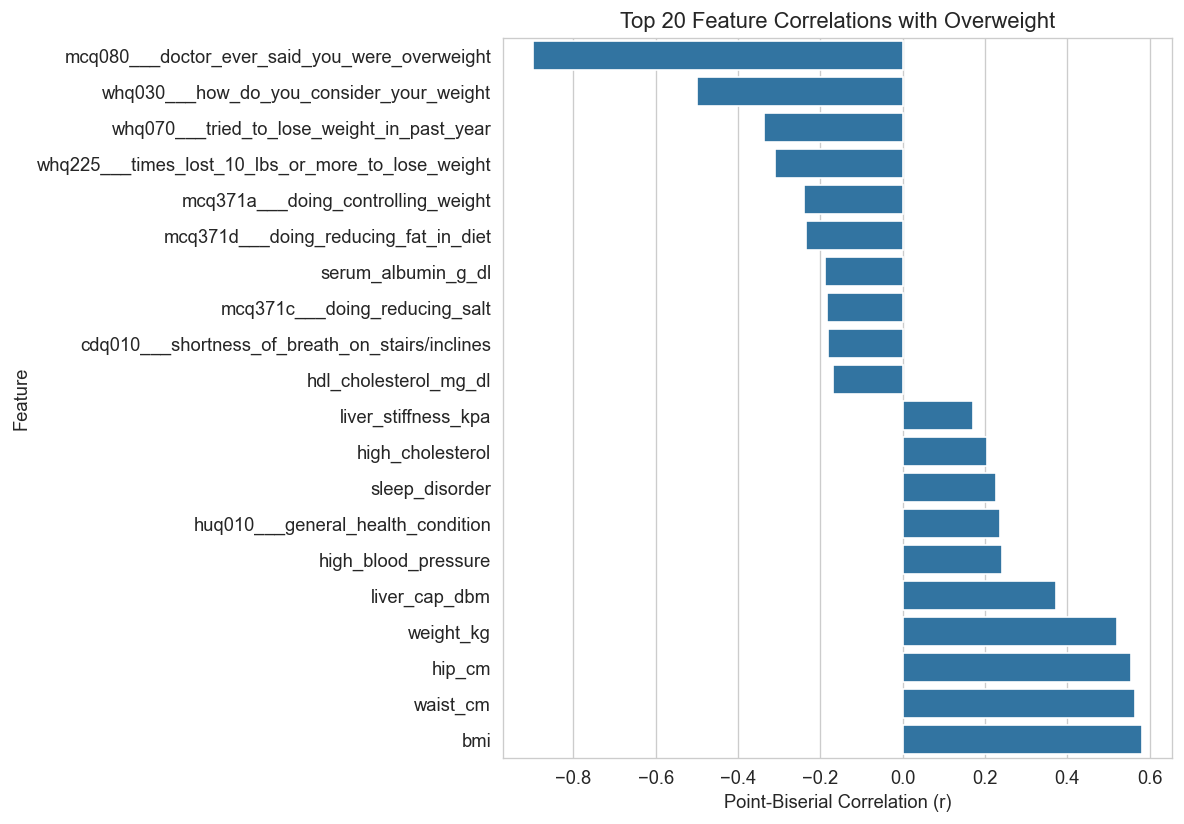

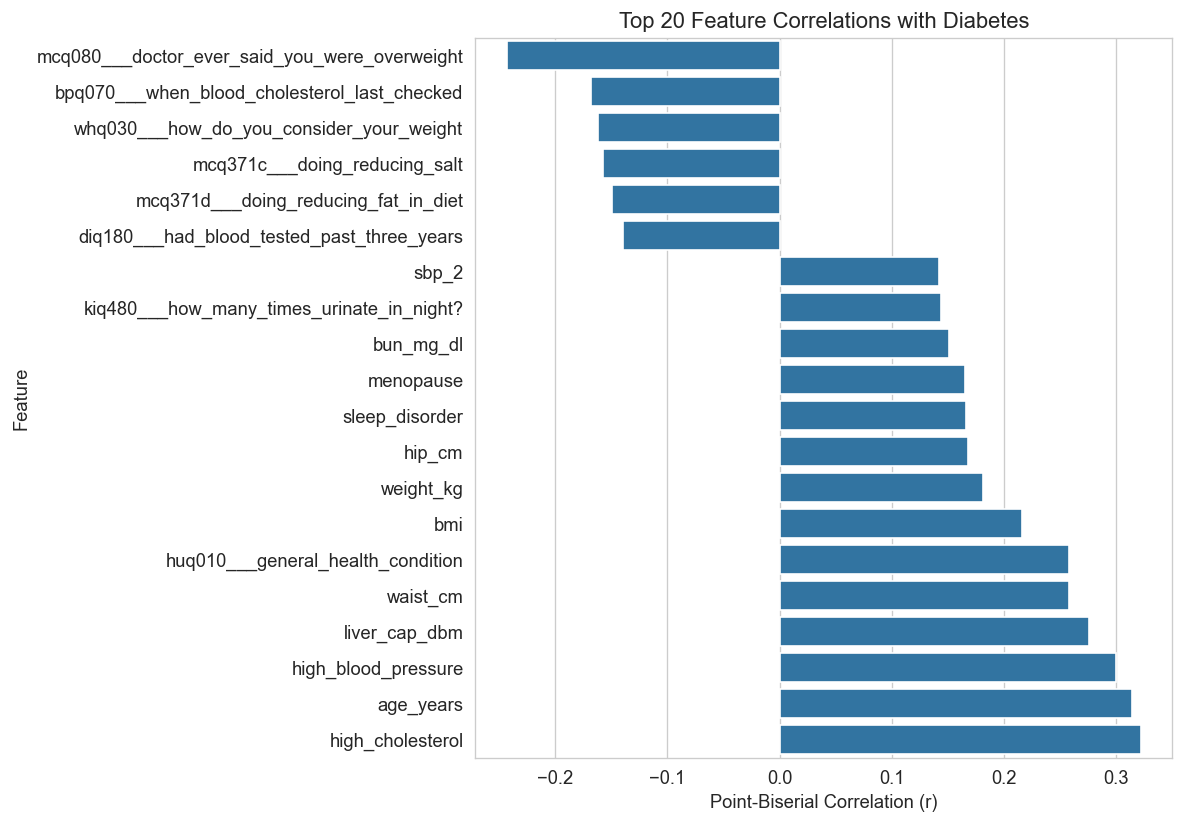

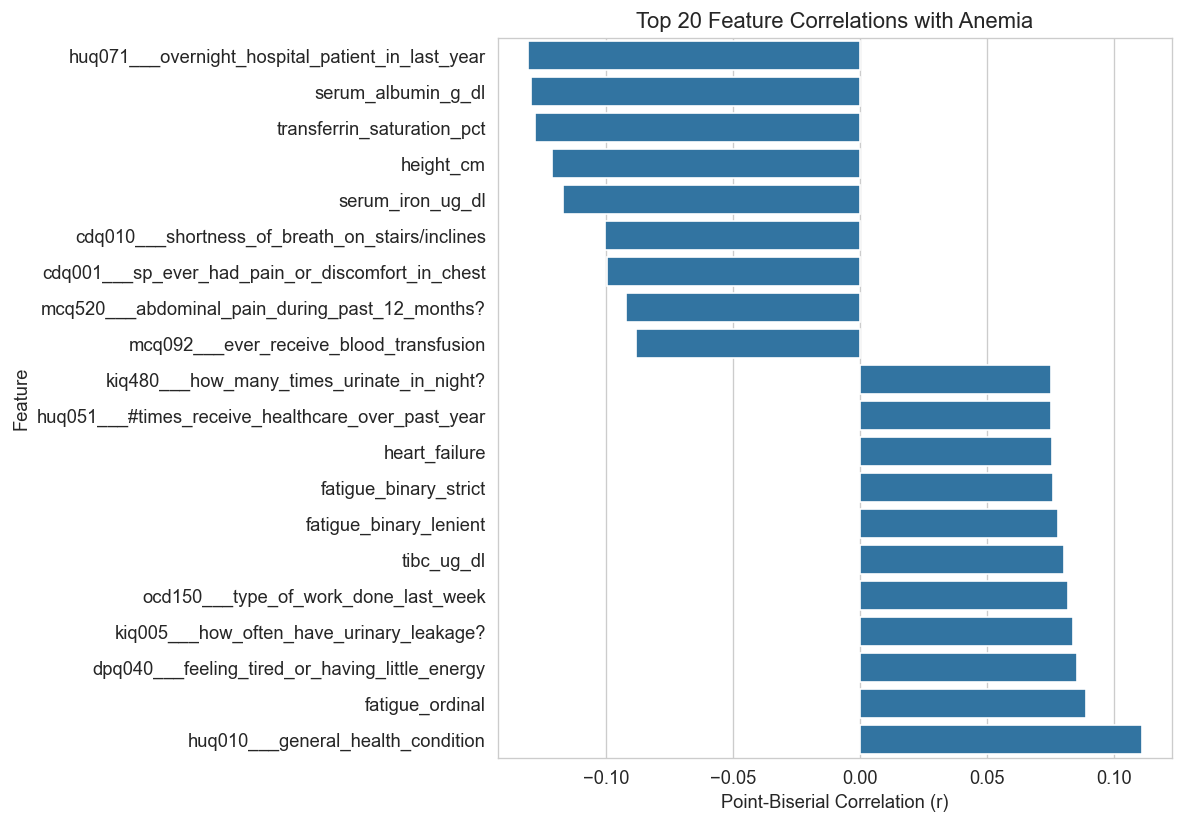

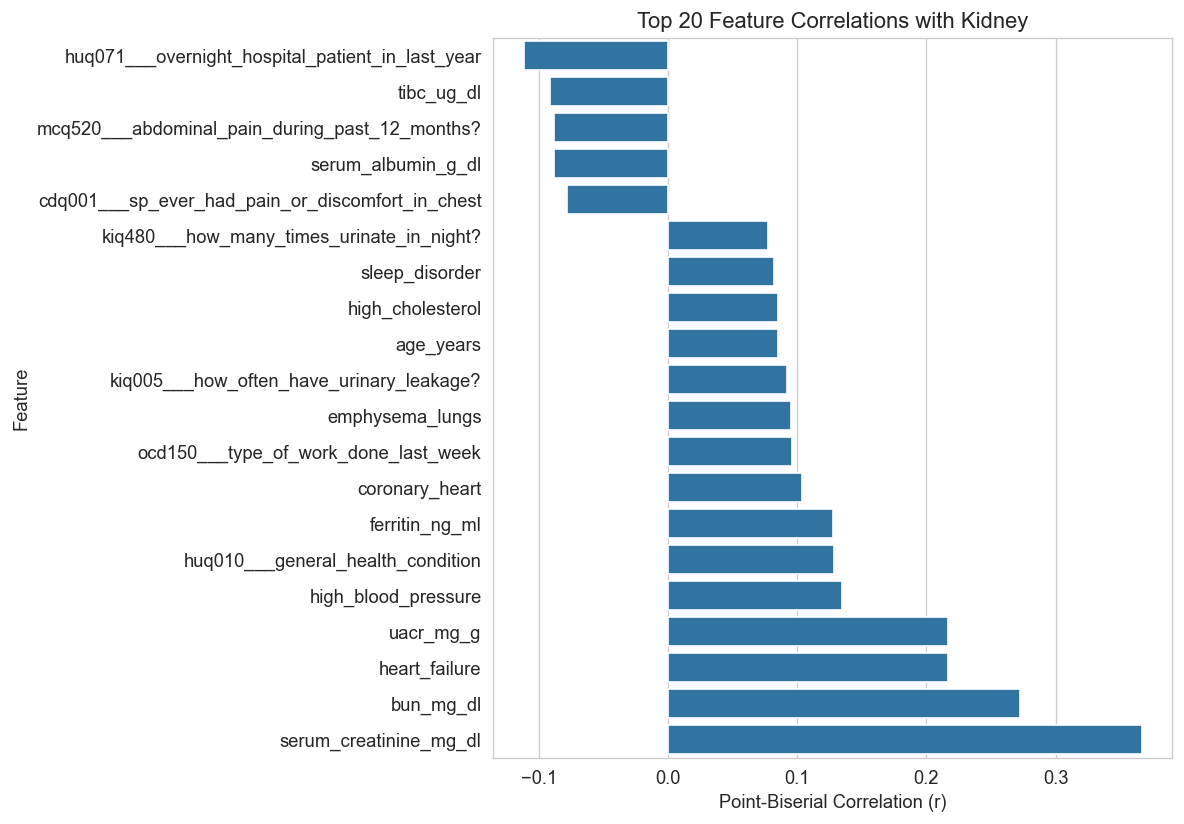

In [30]:
for disease, cdf in disease_feat_corrs.items():

    top20 = cdf.head(20).copy()
    top20 = top20.sort_values('r')

    plt.figure(figsize=(10,7))
    sns.barplot(data=top20, x='r', y='feature')

    plt.title(f"Top 20 Feature Correlations with {disease.capitalize()}")
    plt.xlabel("Point-Biserial Correlation (r)")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()

## Summary — Lifestyle Correlates of Target Diseases

### Overweight
Strong correlations are observed with **body composition and weight-related behaviors**, including BMI, waist circumference, hip circumference, and self-reported weight perception. Lifestyle patterns such as **trying to lose weight, previous weight loss attempts, and diet control behaviors** (e.g., reducing fat or salt intake) also appear prominently. Overweight is additionally associated with **sleep disorders and cardiometabolic conditions** like high blood pressure and high cholesterol.

### Diabetes
Diabetes shows strong associations with **metabolic lifestyle factors**, particularly high cholesterol, high blood pressure, and measures of body composition (BMI, waist circumference, weight). **Age** also plays an important role. Behavioral indicators such as sleep disorders and poorer **self-reported general health** further correlate with diabetes prevalence.

### Anemia
The strongest correlates relate to **fatigue and reduced physical functioning**, including feeling tired, shortness of breath during exertion, and poorer general health status. Indicators of **increased healthcare utilization** (e.g., hospital stays) also appear among the top correlates, reflecting the broader health impact of anemia.

### Kidney Disease
Kidney disease correlates most strongly with **cardiovascular comorbidities and systemic health decline**, including high blood pressure, heart failure, and coronary heart disease. Additional associations include **poorer general health, sleep disorders, and frequent nighttime urination**, which are common symptoms linked to kidney dysfunction.

## Key Non-Lab Signals per Disease (EDA Findings)

The following features show the strongest correlations with each disease and are potential candidates for feature selection in the first baseline models.

### Overweight
Main signals related to body composition, weight perception, and weight-management behavior:

- `bmi`
- `waist_cm`
- `hip_cm`
- `weight_kg`
- `whq030___how_do_you_consider_your_weight`
- `whq070___tried_to_lose_weight_in_past_year`
- `whq225___times_lost_10_lbs_or_more_to_lose_weight`
- `mcq371a___doing_controlling_weight`
- `mcq371d___doing_reducing_fat_in_diet`
- `high_blood_pressure`
- `high_cholesterol`
- `sleep_disorder`
- `huq010___general_health_condition`

### Diabetes
Strong signals reflect metabolic syndrome patterns and aging:

- `age_years`
- `bmi`
- `waist_cm`
- `weight_kg`
- `hip_cm`
- `high_blood_pressure`
- `high_cholesterol`
- `liver_cap_dbm`
- `sleep_disorder`
- `menopause`
- `huq010___general_health_condition`
- `bpq070___when_blood_cholesterol_last_checked`

### Anemia
Signals primarily reflect fatigue symptoms and reduced functional capacity:

- `fatigue_ordinal`
- `fatigue_binary_lenient`
- `fatigue_binary_strict`
- `dpq040___feeling_tired_or_having_little_energy`
- `cdq010___shortness_of_breath_on_stairs/inclines`
- `cdq001___sp_ever_had_pain_or_discomfort_in_chest`
- `huq010___general_health_condition`
- `huq071___overnight_hospital_patient_in_last_year`
- `height_cm`
- `kiq005___how_often_have_urinary_leakage?`

### Kidney Disease
Signals relate strongly to cardiovascular and systemic health:

- `high_blood_pressure`
- `heart_failure`
- `coronary_heart`
- `age_years`
- `sleep_disorder`
- `high_cholesterol`
- `huq010___general_health_condition`
- `kiq480___how_many_times_urinate_in_night?`
- `ocd150___type_of_work_done_last_week`

### lab-signal EDA

In [31]:
lab_num = [
    c for c in LAB_COLS
    if c in df.select_dtypes(include='number').columns
    and c not in MY_DISEASE_COLS
    and df[c].notna().sum() > len(df) * 0.5
]

print(f'Lab numeric features: {len(lab_num)}')
print(lab_num[:20])

Lab numeric features: 197
['URXUMA_albumin_urine_ug_ml', 'URXUMS_albumin_urine_mg_l', 'URDUMALC_albumin_urine_comment_code', 'URXUCR_creatinine_urine_mg_dl', 'URXCRS_creatinine_urine_umol_l', 'URDUCRLC_creatinine_urine_comment_code', 'URDACT_albumin_creatinine_ratio_mg_g', 'LBXSATSI_alanine_aminotransferase_alt_u_l', 'LBDSATLC_alt_comment_code', 'LBXSAL_albumin_refrigerated_serum_g_dl', 'LBDSALSI_albumin_refrigerated_serum_g_l', 'LBXSAPSI_alkaline_phosphatase_alp_iu_l', 'LBXSASSI_aspartate_aminotransferase_ast_u_l', 'LBXSC3SI_bicarbonate_mmol_l', 'LBXSBU_blood_urea_nitrogen_mg_dl', 'LBDSBUSI_blood_urea_nitrogen_mmol_l', 'LBXSCLSI_chloride_mmol_l', 'LBXSCK_creatine_phosphokinase_cpk_iu_l', 'LBXSCR_creatinine_refrigerated_serum_mg_dl', 'LBDSCRSI_creatinine_refrigerated_serum_umol_l']


### Compute correlations for lab features

Goal: Identify lab biomarkers correlated with each disease.

Explanation:
We repeat the same correlation analysis as before, but only for lab variables. This helps identify which biomarkers are most associated with each disease.

In [32]:
lab_disease_corrs = {}

for disease in MY_DISEASE_COLS:
    corrs = []

    for feat in lab_num:
        sub = df[[feat, disease]].dropna()

        if len(sub) < 100 or sub[disease].std() == 0:
            continue

        r, p = pointbiserialr(sub[disease], sub[feat])

        corrs.append({
            'feature': feat,
            'r': r,
            'p': p
        })

    lab_disease_corrs[disease] = (
        pd.DataFrame(corrs)
        .sort_values('r', key=abs, ascending=False)
    )

### Print top lab signals

Goal: See the strongest biomarkers for each disease.

Explanation:
This helps identify which lab tests might realistically be useful features for the model.

In [33]:
print("Top lab correlates per disease:")

for disease, cdf in lab_disease_corrs.items():
    top10 = cdf.head(10)[['feature','r','p']]

    print(f'\n{disease.upper()}:')
    print(top10.to_string(index=False))

Top lab correlates per disease:

OVERWEIGHT:
                                      feature         r            p
       LBXSAL_albumin_refrigerated_serum_g_dl -0.189639 8.222331e-53
      LBDSALSI_albumin_refrigerated_serum_g_l -0.189639 8.222331e-53
          LBXHSCRP_hs_c_reactive_protein_mg_l  0.170936 5.091098e-43
          LBDHDD_direct_hdl_cholesterol_mg_dl -0.169070 2.305778e-42
       LBDHDDSI_direct_hdl_cholesterol_mmol_l -0.168909 2.763853e-42
                        LBXGH_glycohemoglobin  0.167191 3.496061e-42
                       LBXSUA_uric_acid_mg_dl  0.161075 2.200123e-38
                    LBDSUASI_uric_acid_umol_l  0.161073 2.204952e-38
LBXWBCSI_white_blood_cell_count_1000_cells_ul  0.153384 7.508185e-36
   LBDSGLSI_glucose_refrigerated_serum_mmol_l  0.130244 1.442882e-25

DIABETES:
                                   feature         r             p
                     LBXGH_glycohemoglobin  0.495348  0.000000e+00
LBDSGLSI_glucose_refrigerated_serum_mmol_l  0.39603

### Identify realistic lab features for the app

Goal: Mark which lab biomarkers could realistically be used later, based on the German Check-up 35 blood tests.

Explanation:
Some biomarkers (like glucose or cholesterol) are part of routine preventive checkups.
Others (like androstenedione) are not realistic for a consumer health app and should probably be excluded from modeling.

For now we just inspect the top signals clearly.

In [34]:
for disease, cdf in lab_disease_corrs.items():
    print(f"\n=== {disease.upper()} ===")
    display(cdf.head(20))


=== OVERWEIGHT ===


,feature,r,p
9,LBXSAL_albumin_refrigerated_serum_g_dl,-0.189639,8.222331e-53
10,LBDSALSI_albumin_refrigerated_serum_g_l,-0.189639,8.222331e-53
127,LBXHSCRP_hs_c_reactive_protein_mg_l,0.170936,5.091098e-43
115,LBDHDD_direct_hdl_cholesterol_mg_dl,-0.169070,2.305778e-42
116,LBDHDDSI_direct_hdl_cholesterol_mmol_l,-0.168909,2.763853e-42
114,LBXGH_glycohemoglobin,0.167191,3.496061e-42
45,LBXSUA_uric_acid_mg_dl,0.161075,2.200123e-38
46,LBDSUASI_uric_acid_umol_l,0.161073,2.204952e-38
47,LBXWBCSI_white_blood_cell_count_1000_cells_ul,0.153384,7.508185e-36
23,LBDSGLSI_glucose_refrigerated_serum_mmol_l,0.130244,1.442882e-25



=== DIABETES ===


,feature,r,p
114,LBXGH_glycohemoglobin,0.495348,0.000000e+00
23,LBDSGLSI_glucose_refrigerated_serum_mmol_l,0.396037,7.237999e-239
22,LBXSGL_glucose_refrigerated_serum_mg_dl,0.396004,8.005987e-239
29,LBXSOSSI_osmolality_mmol_kg,0.163092,2.547891e-39
173,LBXAND_androstenedione_ng_dl,-0.160695,6.379218e-34
174,LBDANDSI_androstenedione_nmol_l,-0.160657,6.613061e-34
14,LBXSBU_blood_urea_nitrogen_mg_dl,0.151152,5.925439e-34
15,LBDSBUSI_blood_urea_nitrogen_mmol_l,0.151131,6.051538e-34
171,LBD17HSI_17a_hydroxyprogesterone_nmol_l,-0.131081,5.583125e-23
170,LBX17H_17a_hydroxyprogesterone_ng_dl,-0.131068,5.634450e-23



=== ANEMIA ===


,feature,r,p
64,LBXRDW_red_cell_distribution_width,0.269957,5.283253e-110
59,LBXHGB_hemoglobin_g_dl,-0.268789,4.913499e-109
60,LBXHCT_hematocrit,-0.256157,7.282895e-99
62,LBXMC_mean_cell_hgb_conc_g_dl,-0.173344,1.874924e-45
63,LBXMCHSI_mean_cell_hemoglobin_pg,-0.171897,1.023857e-44
58,LBXRBCSI_red_blood_cell_count_million_cells_ul,-0.149962,2.507632e-34
61,LBXMCVSI_mean_cell_volume_fl,-0.146311,9.683076e-33
90,LBXUIB_uibc_serum_ug_dl,0.130306,1.572252e-25
92,LBDUIBSI_uibc_serum_umol_l,0.130220,1.691020e-25
10,LBDSALSI_albumin_refrigerated_serum_g_l,-0.129422,2.829780e-25



=== KIDNEY ===


,feature,r,p
18,LBXSCR_creatinine_refrigerated_serum_mg_dl,0.366615,1.763829e-202
19,LBDSCRSI_creatinine_refrigerated_serum_umol_l,0.366615,1.765922e-202
14,LBXSBU_blood_urea_nitrogen_mg_dl,0.272386,4.764999e-109
15,LBDSBUSI_blood_urea_nitrogen_mmol_l,0.272366,4.945640e-109
112,LBXSF6SI_mefox_oxidation_product_nmol_l,0.217000,7.184247e-47
6,URDACT_albumin_creatinine_ratio_mg_g,0.216533,9.121602e-73
1,URXUMS_albumin_urine_mg_l,0.189438,8.114833e-56
0,URXUMA_albumin_urine_ug_ml,0.189438,8.114833e-56
87,LBDFERSI_ferritin_ug_l,0.127609,7.360295e-25
86,LBXFER_ferritin_ng_ml,0.127609,7.360295e-25


### Identify “allowed” lab tests from Check-up 35

Goal: Define which NHANES lab features are realistic because they are part of the German statutory check-up.

Explanation:
The document shows that the routine check-up includes mainly:

Blood tests

- Total cholesterol

- HDL cholesterol

- LDL cholesterol

- Triglycerides

- Fasting glucose

Urine

- Urine albumin / protein

- Urine glucose

- Urine creatinine

These map directly to NHANES variables.

In [35]:
CHECKUP_LABS = [
    "LBXTC",      # total cholesterol
    "LBDHDD",     # HDL cholesterol
    "LBDLDL",     # LDL cholesterol
    "LBXTR",      # triglycerides
    "LBXGLU",     # fasting glucose
    "URXUMA",     # urine albumin
    "URXUGLU",    # urine glucose
    "URXUCR"      # urine creatinine
]

### Match NHANES column names

NHANES often has variants of the same test (units etc.), so we detect columns containing these codes.

In [36]:
checkup_lab_cols = [
    c for c in lab_num
    if any(code in c for code in CHECKUP_LABS)
]

print("Check-up compatible lab features:")
print(checkup_lab_cols)

Check-up compatible lab features:
['URXUMA_albumin_urine_ug_ml', 'URXUCR_creatinine_urine_mg_dl', 'LBDHDD_direct_hdl_cholesterol_mg_dl', 'LBDHDDSI_direct_hdl_cholesterol_mmol_l', 'LBXTC_total_cholesterol_mg_dl']


### Correlations for Check-up compatible labs

Goal: Evaluate which realistic preventive lab tests correlate with the diseases.

Explanation:
We restrict the analysis to only the lab tests available in the German Check-up, so the results can later be used as model features.

In [37]:
checkup_lab_corrs = {}

for disease in MY_DISEASE_COLS:
    corrs = []

    for feat in checkup_lab_cols:
        sub = df[[feat, disease]].dropna()

        if len(sub) < 100 or sub[disease].std() == 0:
            continue

        r, p = pointbiserialr(sub[disease], sub[feat])

        corrs.append({
            "feature": feat,
            "r": r,
            "p": p
        })

    checkup_lab_corrs[disease] = (
        pd.DataFrame(corrs)
        .sort_values("r", key=abs, ascending=False)
    )

In [38]:
print("Check-up lab correlations:")

for disease, cdf in checkup_lab_corrs.items():
    print(f"\n{disease.upper()}:")
    print(cdf.to_string(index=False))

Check-up lab correlations:

OVERWEIGHT:
                               feature         r            p
   LBDHDD_direct_hdl_cholesterol_mg_dl -0.169070 2.305778e-42
LBDHDDSI_direct_hdl_cholesterol_mmol_l -0.168909 2.763853e-42
         URXUCR_creatinine_urine_mg_dl  0.045149 1.999255e-04
            URXUMA_albumin_urine_ug_ml  0.022437 6.467842e-02
         LBXTC_total_cholesterol_mg_dl  0.013963 2.633853e-01

DIABETES:
                               feature         r            p
LBDHDDSI_direct_hdl_cholesterol_mmol_l -0.122631 6.233071e-23
   LBDHDD_direct_hdl_cholesterol_mg_dl -0.122526 6.779571e-23
            URXUMA_albumin_urine_ug_ml  0.091680 3.904669e-14
         URXUCR_creatinine_urine_mg_dl -0.060381 6.498126e-07
         LBXTC_total_cholesterol_mg_dl -0.005986 6.315883e-01

ANEMIA:
                               feature         r            p
            URXUMA_albumin_urine_ug_ml  0.070076 7.623608e-09
         LBXTC_total_cholesterol_mg_dl -0.054441 1.278508e-05
LBDHDDSI_d

## Laboratory Signals (German Check-up Compatible)

To ensure that potential model features are realistic for the application, laboratory signals were restricted to biomarkers that are part of the **German statutory preventive health check-up (Check-up 35)**. These include lipid panel markers, fasting glucose, and basic urine tests.

### Key Findings

**Overweight**
- Lower **HDL cholesterol** shows the strongest association with overweight.
- Weak associations were observed with **urine creatinine**.
- Total cholesterol showed minimal correlation.

**Diabetes**
- Lower **HDL cholesterol** correlates with diabetes risk.
- **Urine albumin** shows a moderate positive correlation, consistent with early kidney stress related to diabetes.
- Urine creatinine shows a small negative correlation.

**Anemia**
- Very weak correlations were observed with the check-up laboratory panel.
- **Urine albumin** and **total cholesterol** show minor associations but are unlikely to be strong predictors.

**Kidney Disease**
- As expected, **urine albumin** shows a positive relationship with kidney disease.
- HDL cholesterol and urine creatinine show small associations.

### Interpretation

The routine German preventive laboratory panel provides **limited predictive power for most conditions**, except for:
- metabolic markers (HDL cholesterol) related to **overweight and diabetes**
- urine albumin related to **kidney disease**

This suggests that **non-laboratory features (symptoms, lifestyle, anthropometrics)** will likely carry the majority of predictive signal for the baseline models.

## Key Signals per Disease (EDA Summary)

The following features showed the strongest correlations with each disease.  
Features are grouped into **non-lab signals (questionnaire / lifestyle / anthropometrics)** and **check-up compatible laboratory signals**.

---

### Overweight

**Non-lab features**
- `bmi`
- `waist_cm`
- `hip_cm`
- `weight_kg`
- `whq030___how_do_you_consider_your_weight`
- `whq070___tried_to_lose_weight_in_past_year`
- `whq225___times_lost_10_lbs_or_more_to_lose_weight`
- `mcq371a___doing_controlling_weight`
- `mcq371d___doing_reducing_fat_in_diet`
- `sleep_disorder`
- `high_blood_pressure`
- `high_cholesterol`
- `huq010___general_health_condition`

**Check-up compatible lab signals**
- `LBDHDD_direct_hdl_cholesterol_mg_dl`
- `LBDHDDSI_direct_hdl_cholesterol_mmol_l`
- `URXUCR_creatinine_urine_mg_dl`
- `URXUMA_albumin_urine_ug_ml`
- `LBXTC_total_cholesterol_mg_dl`

---

### Diabetes

**Non-lab features**
- `age_years`
- `bmi`
- `waist_cm`
- `weight_kg`
- `hip_cm`
- `high_blood_pressure`
- `high_cholesterol`
- `sleep_disorder`
- `menopause`
- `huq010___general_health_condition`
- `bpq070___when_blood_cholesterol_last_checked`

**Check-up compatible lab signals**
- `LBDHDD_direct_hdl_cholesterol_mg_dl`
- `LBDHDDSI_direct_hdl_cholesterol_mmol_l`
- `URXUMA_albumin_urine_ug_ml`
- `URXUCR_creatinine_urine_mg_dl`
- `LBXTC_total_cholesterol_mg_dl`

---

### Anemia

**Non-lab features**
- `fatigue_ordinal`
- `fatigue_binary_lenient`
- `fatigue_binary_strict`
- `dpq040___feeling_tired_or_having_little_energy`
- `cdq010___shortness_of_breath_on_stairs/inclines`
- `cdq001___sp_ever_had_pain_or_discomfort_in_chest`
- `huq010___general_health_condition`
- `huq071___overnight_hospital_patient_in_last_year`
- `height_cm`

**Check-up compatible lab signals**
- `URXUMA_albumin_urine_ug_ml`
- `LBXTC_total_cholesterol_mg_dl`

*(Lab signals for anemia were generally weak in the statutory check-up panel.)*

---

### Kidney Disease

**Non-lab features**
- `high_blood_pressure`
- `heart_failure`
- `coronary_heart`
- `age_years`
- `sleep_disorder`
- `high_cholesterol`
- `huq010___general_health_condition`
- `kiq480___how_many_times_urinate_in_night?`
- `ocd150___type_of_work_done_last_week`

**Check-up compatible lab signals**
- `URXUMA_albumin_urine_ug_ml`
- `URXUCR_creatinine_urine_mg_dl`
- `LBDHDD_direct_hdl_cholesterol_mg_dl`
- `LBDHDDSI_direct_hdl_cholesterol_mmol_l`